# 📊 Predicción de Rotación Voluntaria
### Análisis exploratorio de datos aplicado a People Analytics
- **Asignatura:** Análisis de Datos I  
- **Taller 1:** Comparte tu análisis exploratorio de datos  

---

## 1. 🎯 Descripción del problema e impacto

### 1.1 Contexto organizacional
La organización cuenta con diferentes colaboradores y áreas que son importantes para el funcionamiento de sus procesos. La salida inesperada de un colaborador puede generar dificultades para continuar las actividades y cubrir rápidamente su puesto.

### 1.2 Problema identificado
Actualmente no se puede anticipar con suficiente tiempo qué colaboradores podrían presentar una renuncia voluntaria. Esto dificulta preparar reemplazos y puede generar pérdida de conocimiento y afectar la continuidad de algunos procesos.

### 1.3 Áreas y procesos afectados
Puede afectar a cualquiera de las áreas de la organización donde se presentan las salidas, especialmente cuando se trata de cargos importantes.

### 1.4 Impacto en la organización
Una renuncia no anticipada puede generar:
- Pérdida de conocimiento y experiencia.
- Sobrecarga de trabajo para otros colaboradores.
- Posibles interrupciones en procesos importantes.

### 1.5 Indicadores (KPI)
El principal indicador que se busca mejorar es el **porcentaje de renuncias voluntarias no anticipadas**, expresada entre 0 % y 100 %, para identificar quiénes presentan mayor riesgo.

---

## 2. 🗂️ Complejidad y disponibilidad de los datos

### 2.1 Datos requeridos
Para analizar la rotación de empleados necesitamos información relacionada con sus características personales, laborales y de satisfacción:
- Edad y estado civil.
- Área y cargo.
- Salario.
- Antigüedad en la empresa.
- Satisfacción laboral.
- Desempeño.
- Horas extras.
- Viajes de trabajo.
- Formación.
- Tiempo en el cargo.
- Promociones.
- **Attrition**, que indica si el empleado se retiró.

### 2.2 Fuente de los datos
Los datos utilizados fueron obtenidos de Kaggle, en el conjunto *IBM HR Analytics Employee Attrition & Performance*. Es importante aclarar que se trata de un conjunto de datos ficticio, por lo que será utilizado como referencia para desarrollar el análisis y el prototipo.

### 2.3 Descripción del conjunto de datos
El conjunto de datos tiene 1.470 registros de empleados y 35 variables. Incluye información relacionada con aspectos personales, laborales, económicos y de satisfacción de los empleados.  
La variable que nos interesa principalmente es:
- **`Attrition` (rotación) →** indica si el empleado se retiró de la empresa (`Yes`) o permaneció (`No`).

### 2.4 Variables disponibles
El conjunto de datos contiene **35 variables** relacionadas con las características personales, laborales y de satisfacción de los empleados.

### 2.5 Complejidad del problema
El problema tiene una complejidad media, porque tenemos diferentes tipos de variables y debemos analizar cómo se relacionan con la rotación. Además, algunas variables son numéricas y otras son categóricas, por lo que será necesario preparar los datos antes de realizar el análisis.  
En este taller comenzaremos con un análisis exploratorio para identificar patrones y posibles factores relacionados con la rotación voluntaria.

---

## 3. 🤖 Justificación del uso de IA y Ciencia de Datos

### 3.1 Enfoque analítico
Se utilizarán técnicas de **Ciencia de Datos** para analizar la información de los empleados e identificar posibles factores relacionados con la rotación.

### 3.2 Técnica de Ciencia de Datos propuesta
Se propone utilizar un modelo de **clasificación**, ya que queremos predecir si un empleado tiene mayor o menor probabilidad de presentar una renuncia. El modelo permitirá obtener una **probabilidad de rotación** para cada empleado.

### 3.3 Aplicación al problema de rotación voluntaria
El modelo analizará variables como la edad, salario, satisfacción laboral, horas extras, antigüedad, cargo y otros factores disponibles en los datos. Con esta información se buscará identificar patrones que puedan estar relacionados con la decisión de un empleado de retirarse.

### 3.4 Beneficios esperados
- Identificar empleados con mayor probabilidad de rotación.
- Conocer algunos factores relacionados con las renuncias.
- Apoyar la toma de decisiones de Gestión Humana.
- Facilitar la creación de estrategias de retención.
- Anticipar posibles necesidades de reemplazo.

---

## 4. 🎯 Pregunta de análisis SMART

> **¿Podemos identificar, a partir de las características laborales y personales de los empleados, cuáles presentan una mayor probabilidad de rotación voluntaria, con el fin de apoyar las decisiones de Gestión Humana?**

- **Específica (Specific):** La pregunta se enfoca en identificar los empleados que presentan una mayor probabilidad de rotación voluntaria.
- **Medible (Measurable):** El resultado se podrá medir mediante la **probabilidad de rotación**, expresada como un porcentaje entre 0 % y 100 %.

## 5. 🔎 Análisis Exploratorio de Datos (EDA)

### 5.1 Carga de librerías
Importamos las librerías necesarias para el procesamiento, análisis y modelado de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Configuración básica de visualización
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

### 5.2 Carga del conjunto de datos y estandarización de columnas
Cargamos el conjunto de datos y renombramos las columnas a español para mayor claridad en el análisis.

In [2]:
df = pd.read_csv("HR-Employee-Attrition.csv")

# Renombrar columnas a nombres en español
df = df.rename(columns={
    "Age": "edad",
    "Attrition": "rotacion",
    "BusinessTravel": "viaje_negocio",
    "DailyRate": "tarifa_diaria",
    "Department": "departamento",
    "DistanceFromHome": "distancia_casa",
    "Education": "nivel_educativo",
    "EducationField": "area_estudio",
    "EmployeeCount": "total_empleados",
    "EmployeeNumber": "id_empleado",
    "EnvironmentSatisfaction": "satisfaccion_ambiente",
    "Gender": "genero",
    "HourlyRate": "tarifa_hora",
    "JobInvolvement": "compromiso_trabajo",
    "JobLevel": "nivel_cargo",
    "JobRole": "cargo",
    "JobSatisfaction": "satisfaccion_trabajo",
    "MaritalStatus": "estado_civil",
    "MonthlyIncome": "ingreso_mensual",
    "MonthlyRate": "tarifa_mensual",
    "NumCompaniesWorked": "empresas_trabajadas",
    "Over18": "mayor_18",
    "OverTime": "horas_extras",
    "PercentSalaryHike": "aumento_salarial",
    "PerformanceRating": "evaluacion_desempeno",
    "RelationshipSatisfaction": "satisfaccion_relaciones",
    "StandardHours": "horas_estandar",
    "StockOptionLevel": "nivel_opciones_acciones",
    "TotalWorkingYears": "anios_experiencia",
    "TrainingTimesLastYear": "capacitaciones_ultimo_año",
    "WorkLifeBalance": "equilibrio_vida_trabajo",
    "YearsAtCompany": "anios_empresa",
    "YearsInCurrentRole": "anios_cargo_actual",
    "YearsSinceLastPromotion": "anios_ultima_promocion",
    "YearsWithCurrManager": "anios_jefe_actual"
})

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head(10)

Dimensiones del dataset: 1470 filas y 35 columnas


,edad,rotacion,viaje_negocio,tarifa_diaria,departamento,distancia_casa,nivel_educativo,area_estudio,total_empleados,id_empleado,...,satisfaccion_relaciones,horas_estandar,nivel_opciones_acciones,anios_experiencia,capacitaciones_ultimo_año,equilibrio_vida_trabajo,anios_empresa,anios_cargo_actual,anios_ultima_promocion,anios_jefe_actual
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### 5.3 Calidad y estructura de los datos
Evaluamos la presencia de valores nulos (faltantes) y registros duplicados en el conjunto de datos.

In [3]:
valores_faltantes = df.isnull().sum()
duplicados = df.duplicated().sum()

print(f"Total de registros duplicados: {duplicados}")
print(f"Total de valores faltantes:     {valores_faltantes.sum()}")

resumen_calidad = pd.DataFrame({
    "Tipo de Dato": df.dtypes,
    "Valores Faltantes": valores_faltantes,
    "Porcentaje Faltante (%)": (valores_faltantes / len(df)) * 100
})
resumen_calidad.head(15)

Total de registros duplicados: 0
Total de valores faltantes:     0


,Tipo de Dato,Valores Faltantes,Porcentaje Faltante (%)
edad,int64,0,0.0
rotacion,str,0,0.0
viaje_negocio,str,0,0.0
tarifa_diaria,int64,0,0.0
departamento,str,0,0.0
distancia_casa,int64,0,0.0
nivel_educativo,int64,0,0.0
area_estudio,str,0,0.0
total_empleados,int64,0,0.0
id_empleado,int64,0,0.0


### 5.4 Análisis de variables numéricas
Identificamos las variables de tipo numérico y calculamos su resumen estadístico descriptivo.

In [4]:
variables_numericas = df.select_dtypes(include="number")
print(f"Variables numéricas ({len(variables_numericas.columns)}): {list(variables_numericas.columns)}")
variables_numericas.describe().T

Variables numéricas (26): ['edad', 'tarifa_diaria', 'distancia_casa', 'nivel_educativo', 'total_empleados', 'id_empleado', 'satisfaccion_ambiente', 'tarifa_hora', 'compromiso_trabajo', 'nivel_cargo', 'satisfaccion_trabajo', 'ingreso_mensual', 'tarifa_mensual', 'empresas_trabajadas', 'aumento_salarial', 'evaluacion_desempeno', 'satisfaccion_relaciones', 'horas_estandar', 'nivel_opciones_acciones', 'anios_experiencia', 'capacitaciones_ultimo_año', 'equilibrio_vida_trabajo', 'anios_empresa', 'anios_cargo_actual', 'anios_ultima_promocion', 'anios_jefe_actual']


,count,mean,std,min,25%,50%,75%,max
edad,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
tarifa_diaria,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
distancia_casa,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
nivel_educativo,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
total_empleados,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
id_empleado,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
satisfaccion_ambiente,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
tarifa_hora,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
compromiso_trabajo,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
nivel_cargo,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


#### Distribución de las variables numéricas (Histogramas)
Graficamos la distribución de frecuencia de todas las variables numéricas para identificar sesgos o valores atípicos.

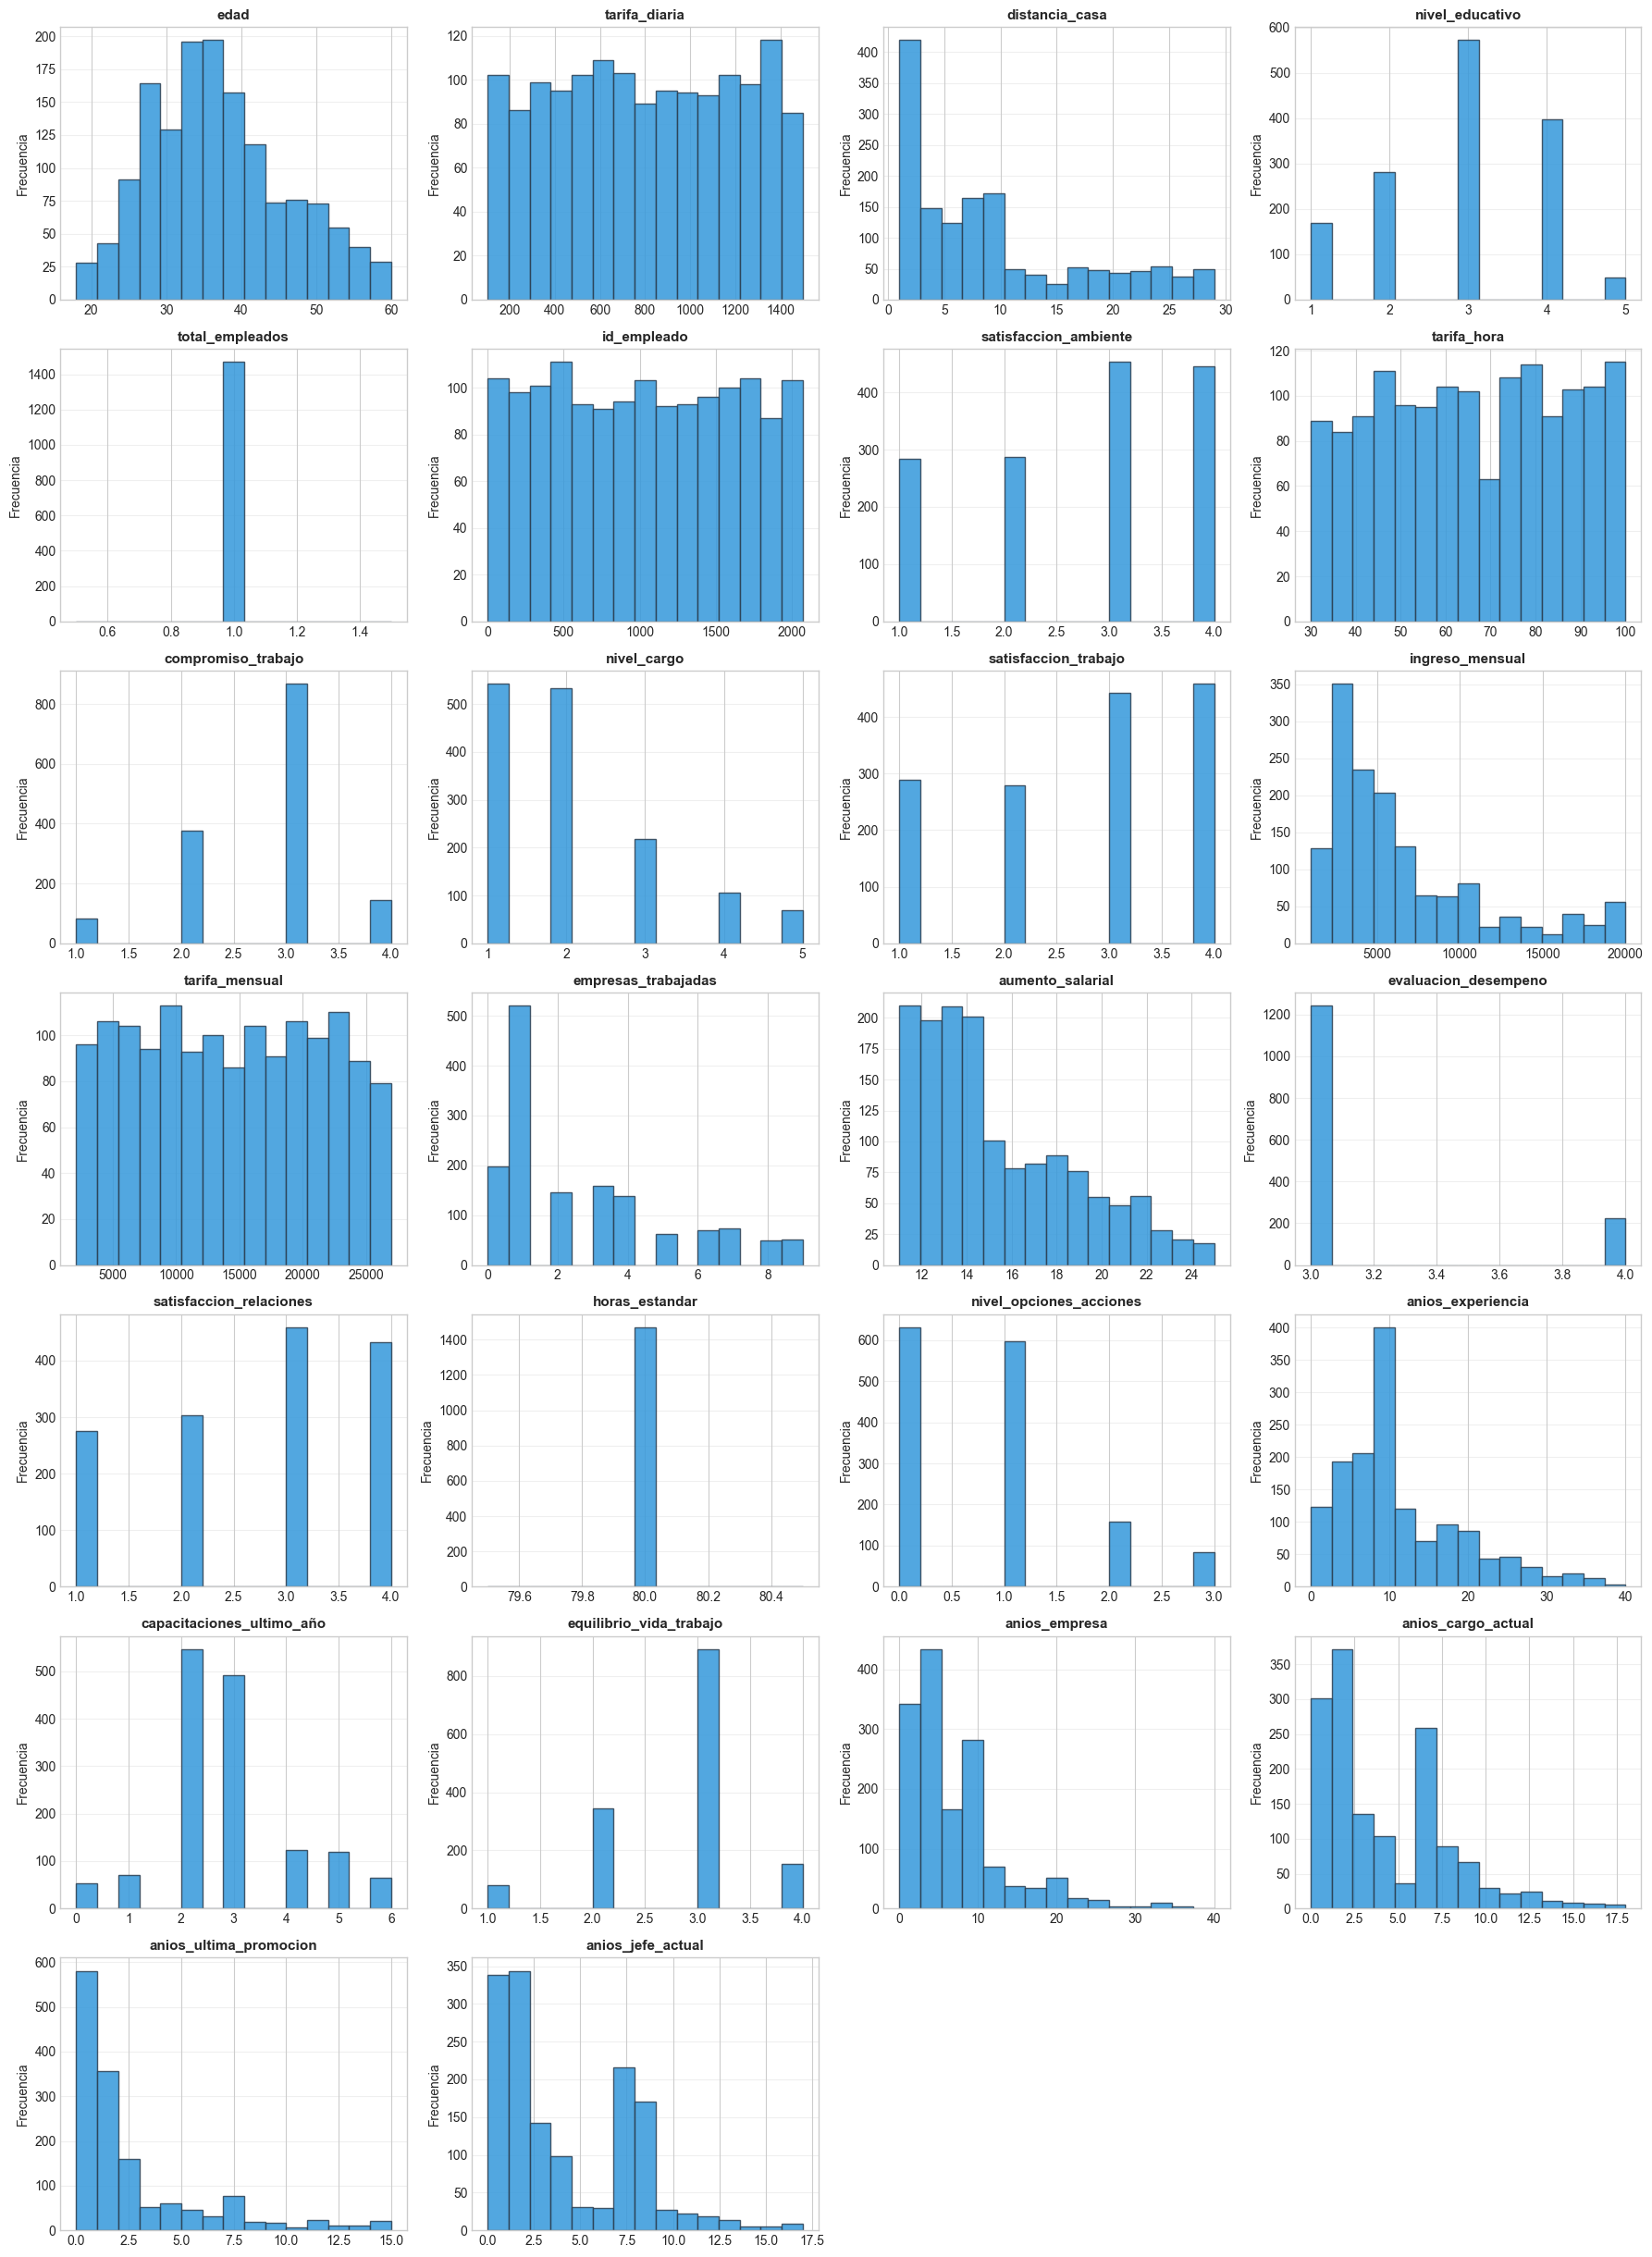

In [5]:
cantidad_variables = len(variables_numericas.columns)
columnas = 4
filas = math.ceil(cantidad_variables / columnas)

fig, axes = plt.subplots(filas, columnas, figsize=(18, filas * 3.5))
axes = axes.flatten()

for i, variable in enumerate(variables_numericas.columns):
    axes[i].hist(df[variable], bins=15, color="#3498db", edgecolor="#2c3e50", alpha=0.85)
    axes[i].set_title(variable, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(axis="y", alpha=0.3)

for j in range(cantidad_variables, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 5.5 Análisis de la variable objetivo (`rotacion`)
Analizamos la proporción de empleados que permanecieron (`No`) frente a quienes presentaron renuncia voluntaria (`Yes`).

Permanecen (No): 1,233 (83.88%)
Renunciaron (Yes): 237 (16.12%)


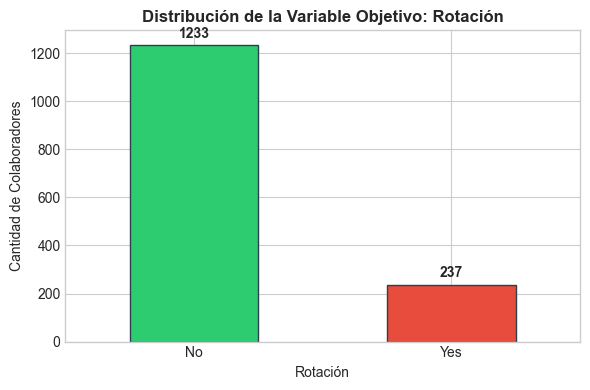

In [6]:
rotacion_counts = df["rotacion"].value_counts()
rotacion_pct = df["rotacion"].value_counts(normalize=True) * 100

print(f"Permanecen (No): {rotacion_counts.get('No', 0):,} ({rotacion_pct.get('No', 0):.2f}%)")
print(f"Renunciaron (Yes): {rotacion_counts.get('Yes', 0):,} ({rotacion_pct.get('Yes', 0):.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = rotacion_counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="#2c3e50")
ax.set_title("Distribución de la Variable Objetivo: Rotación", fontsize=12, fontweight="bold")
ax.set_xlabel("Rotación")
ax.set_ylabel("Cantidad de Colaboradores")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontweight="bold")

plt.tight_layout()
plt.show()

### 5.6 Relación entre variables categóricas y la rotación
Evaluamos la tasa de rotación en porcentaje según diferentes variables categóricas laborales y sociodemográficas.

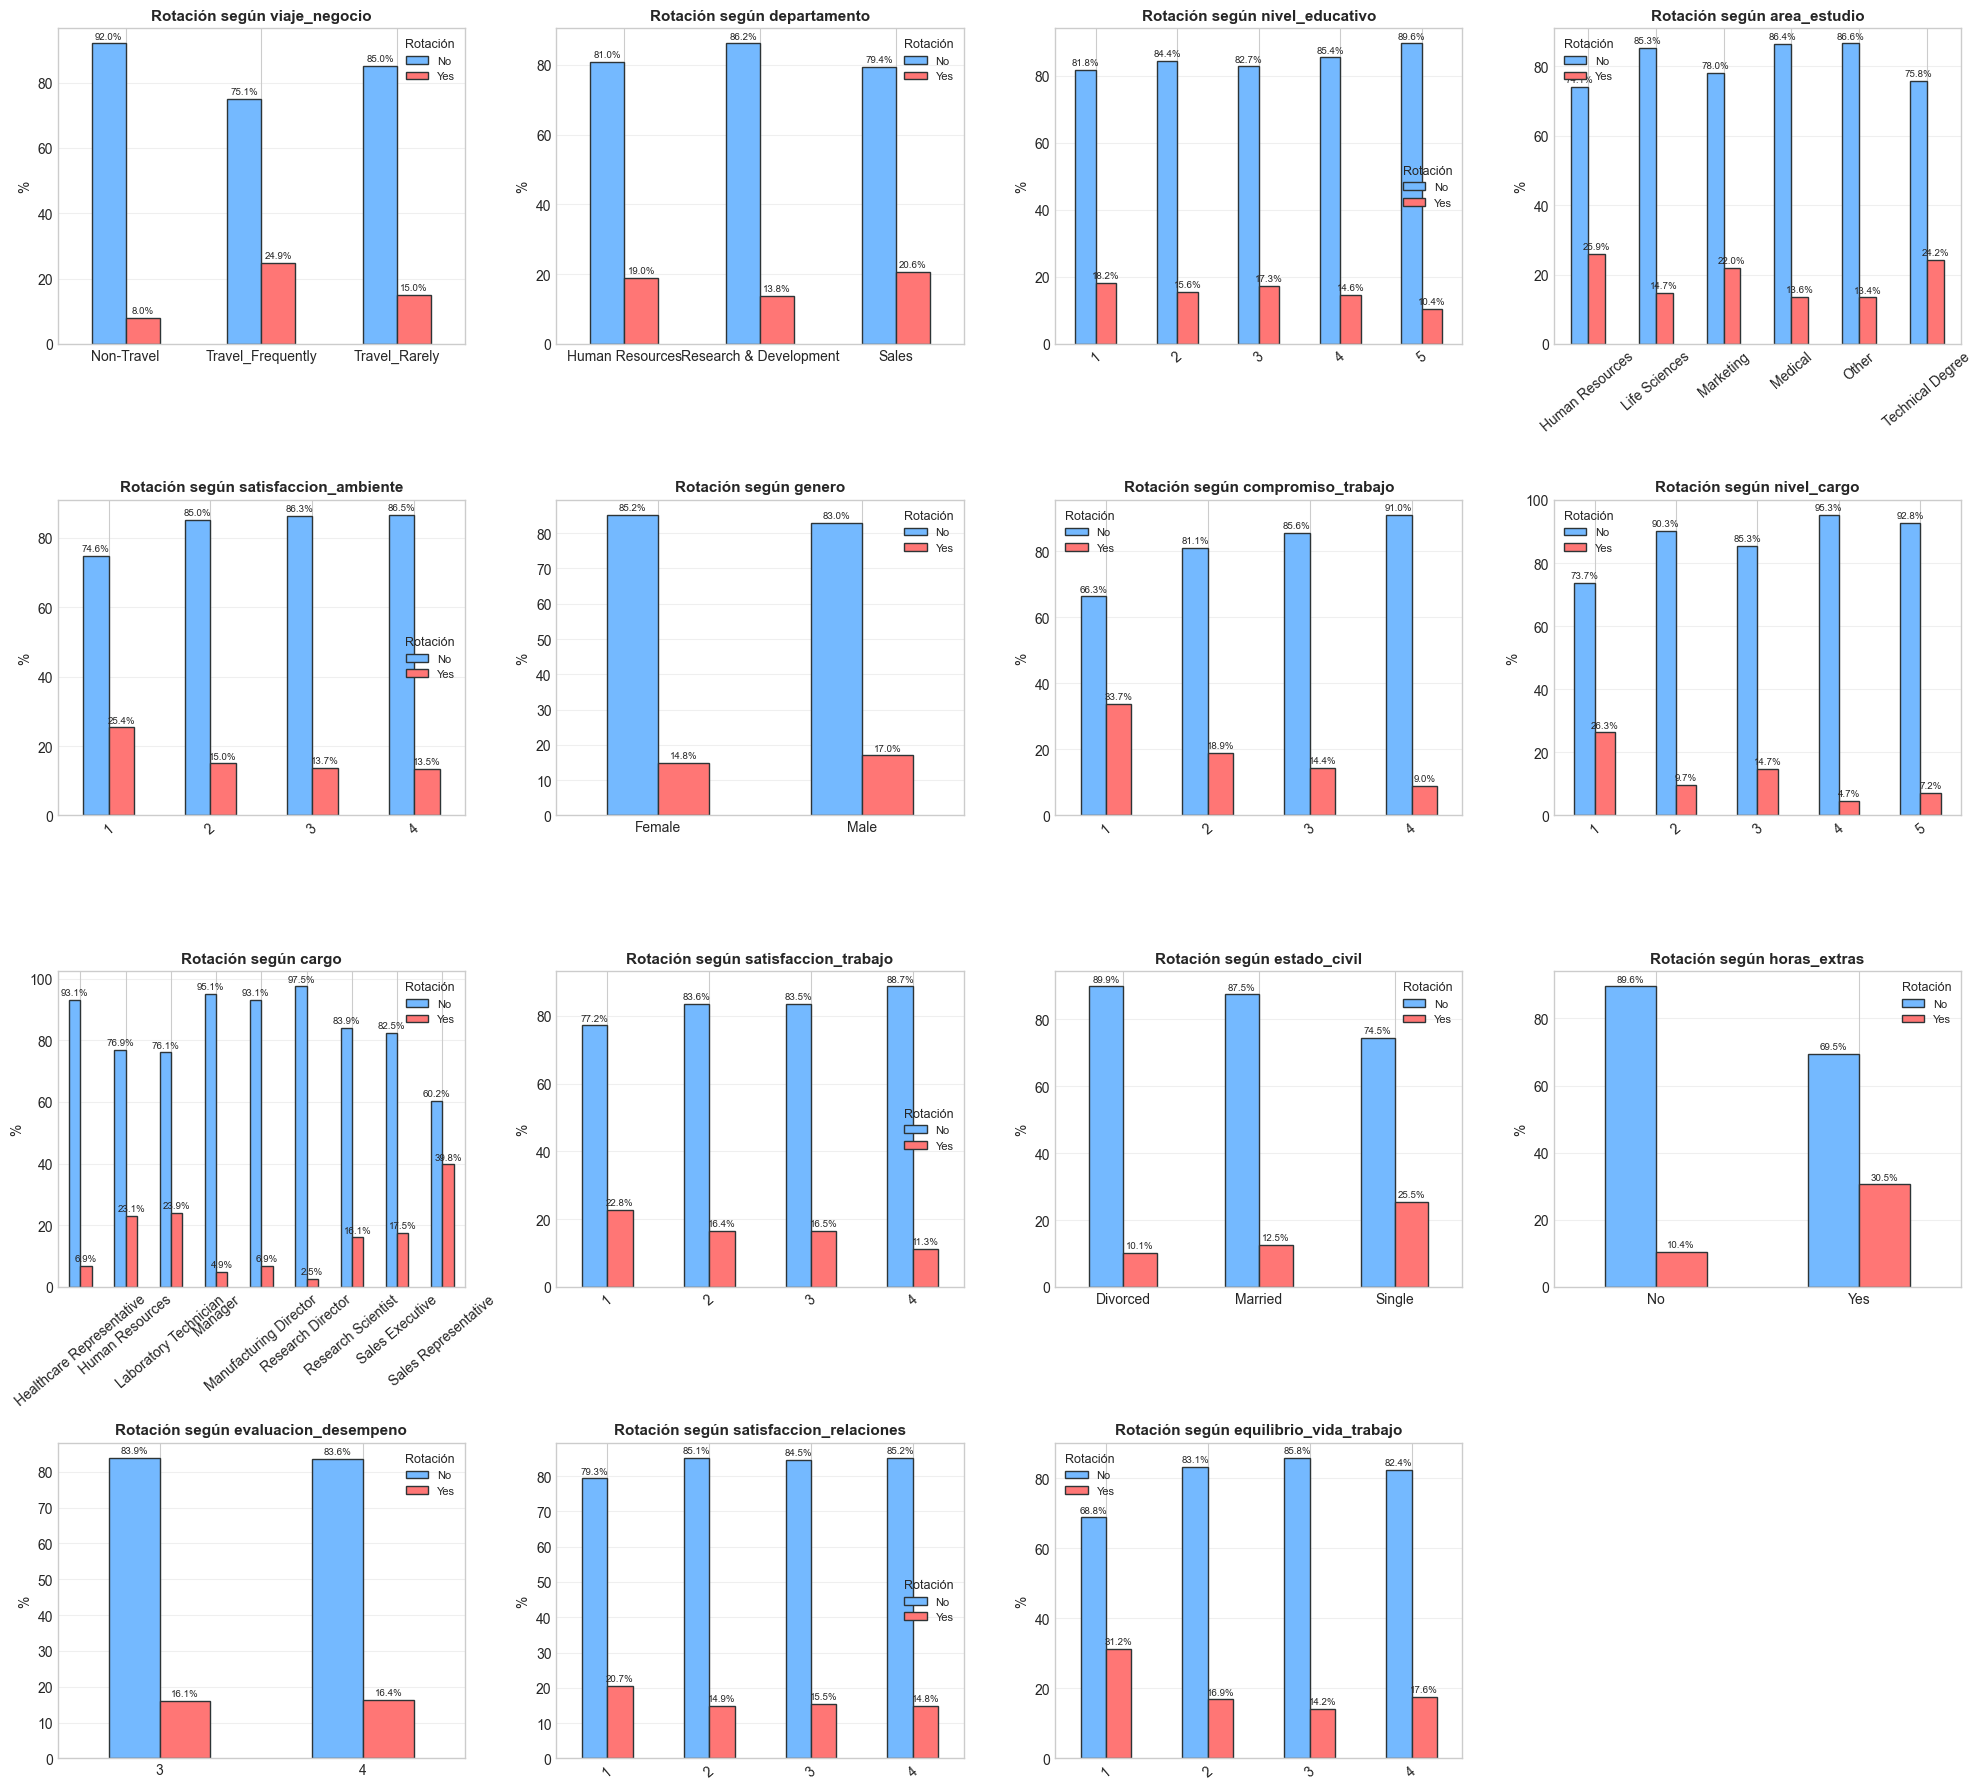

In [7]:
variables_categoricas = [
    "viaje_negocio",
    "departamento",
    "nivel_educativo",
    "area_estudio",
    "satisfaccion_ambiente",
    "genero",
    "compromiso_trabajo",
    "nivel_cargo",
    "cargo",
    "satisfaccion_trabajo",
    "estado_civil",
    "horas_extras",
    "evaluacion_desempeno",
    "satisfaccion_relaciones",
    "equilibrio_vida_trabajo"
]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, variable in enumerate(variables_categoricas):
    tabla = pd.crosstab(df[variable], df["rotacion"], normalize="index") * 100
    tabla.plot(kind="bar", ax=axes[i], color=["#74b9ff", "#ff7675"], edgecolor="#2d3436")
    axes[i].set_title(f"Rotación según {variable}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("%")
    axes[i].tick_params(axis="x", rotation=40 if df[variable].nunique() > 3 else 0)
    axes[i].grid(axis="y", alpha=0.3)
    axes[i].legend(title="Rotación", fontsize=8, title_fontsize=9)
    
    for contenedor in axes[i].containers:
        axes[i].bar_label(contenedor, fmt="%.1f%%", padding=2, fontsize=7)

for j in range(len(variables_categoricas), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 5.7 Hallazgos principales del Análisis Exploratorio
- **Horas extras:** Representa un diferenciador clave: la rotación es del **30,5%** entre quienes realizan horas extras frente al **10,4%** entre quienes no las realizan.
- **Compromiso con el trabajo:** En el nivel 1 de compromiso la rotación alcanza el **33,7%**, mientras que en el nivel 4 disminuye a **9,0%**.
- **Satisfacción con el trabajo y el ambiente:** Niveles bajos de satisfacción se correlacionan con mayores tasas de retiro voluntario.
- **Estado civil:** Los empleados solteros exhiben una tasa de rotación del **25,5%**, sensiblemente mayor a la de colaboradores casados (**12,5%**).
- **Nivel de cargo:** Los niveles de entrada (nivel 1) presentan una rotación del **26,3%**, mientras que en niveles superiores (nivel 4) es de tan solo **4,7%**.
- **Cargo y viajes:** Áreas como representantes de ventas (*Sales Representative*) y personal con viajes frecuentes reflejan una mayor propensión a la desvinculación.

---

## 6. 🧠 Prototipo de Solución Predictiva (Machine Learning)

Implementamos un modelo de **Regresión Logística** para estimar la probabilidad individual de rotación de cada colaborador.

### 6.1 Preparación y selección de variables
- Codificamos la variable objetivo binaria: $0 = 	ext{No}$, $1 = 	ext{Yes}$.
- Excluimos variables constantes o que actúan como identificadores sin poder predictivo (`id_empleado`, `total_empleados`, `horas_estandar`, `mayor_18`).

In [8]:
# Variable objetivo binaria
y = df["rotacion"].map({"No": 0, "Yes": 1})

# Predictoras (excluyendo identificadores y constantes)
X = df.drop(columns=[
    "rotacion",
    "id_empleado",
    "total_empleados",
    "horas_estandar",
    "mayor_18"
])

print(f"Dimensiones de variables predictoras (X): {X.shape[0]} registros y {X.shape[1]} columnas")
print(f"Distribución de y: No={int((y==0).sum())} ({((y==0).mean()*100):.1f}%), Yes={int((y==1).sum())} ({((y==1).mean()*100):.1f}%)")

Dimensiones de variables predictoras (X): 1470 registros y 30 columnas
Distribución de y: No=1233 (83.9%), Yes=237 (16.1%)


### 6.2 División de los datos en Entrenamiento y Prueba
Dividimos los datos en 80% para entrenamiento y 20% para evaluación, usando estratificación para mantener el balance de clases en ambos subconjuntos.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Registros en entrenamiento (80%): {X_train.shape[0]}")
print(f"Registros en prueba (20%):        {X_test.shape[0]}")

Registros en entrenamiento (80%): 1176
Registros en prueba (20%):        294


### 6.3 Preprocesamiento: Estandarización y One-Hot Encoding
- Aplicamos `StandardScaler` a las variables numéricas.
- Aplicamos `OneHotEncoder(handle_unknown='ignore')` a las variables categóricas.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

variables_numericas_modelo = X.select_dtypes(include=["int64", "float64"]).columns
variables_categoricas_modelo = X.select_dtypes(include=["object", "string"]).columns

preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), variables_numericas_modelo),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas_modelo)
    ]
)

X_train_preparado = preprocesamiento.fit_transform(X_train)
X_test_preparado = preprocesamiento.transform(X_test)

print(f"Variables predictoras iniciales:               {X.shape[1]}")
print(f"Variables resultantes tras One-Hot Encoding:   {X_train_preparado.shape[1]}")

Variables predictoras iniciales:               30
Variables resultantes tras One-Hot Encoding:   51


### 6.4 Entrenamiento del modelo de Regresión Logística
Entrenamos el clasificador de regresión logística con el conjunto de entrenamiento preparado.

In [11]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_preparado, y_train)
print("✅ Modelo de Regresión Logística entrenado correctamente.")

✅ Modelo de Regresión Logística entrenado correctamente.


### 6.5 Predicciones y Probabilidades
Obtenemos las predicciones de clase y las probabilidades estimadas de renuncia voluntaria para el conjunto de prueba.

In [12]:
y_pred = modelo.predict(X_test_preparado)
y_prob = modelo.predict_proba(X_test_preparado)[:, 1]

print(f"Total de predicciones generadas: {len(y_pred)}")
print(f"Probabilidad promedio de rotación en prueba: {y_prob.mean() * 100:.2f}%")

Total de predicciones generadas: 294
Probabilidad promedio de rotación en prueba: 14.99%


### 6.6 Evaluación del modelo
Calculamos las métricas de rendimiento en prueba: **Accuracy**, **Precision**, **Recall**, **F1-Score** y **ROC-AUC**.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metricas_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Valor": [f"{accuracy:.2%}", f"{precision:.2%}", f"{recall:.2%}", f"{f1:.2%}", f"{roc_auc:.2%}"]
})
metricas_df

,Métrica,Valor
0,Accuracy,86.05%
1,Precision,61.54%
2,Recall,34.04%
3,F1-Score,43.84%
4,ROC-AUC,81.15%


### 6.7 Matriz de Confusión
Evaluamos el balance entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

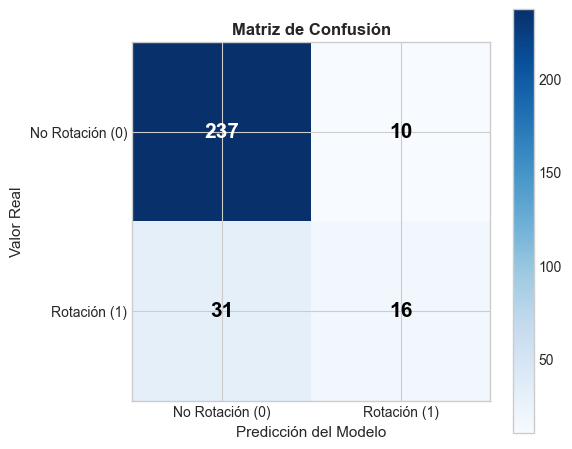

In [14]:
matriz = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(matriz, cmap="Blues", interpolation="nearest")
fig.colorbar(cax)

ax.set_title("Matriz de Confusión", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicción del Modelo", fontsize=11)
ax.set_ylabel("Valor Real", fontsize=11)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Rotación (0)", "Rotación (1)"])
ax.set_yticklabels(["No Rotación (0)", "Rotación (1)"])

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        ax.text(
            j, i, str(matriz[i, j]),
            ha="center", va="center",
            fontsize=15, fontweight="bold",
            color="white" if matriz[i, j] > matriz.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

### 6.8 Ranking de empleados con mayor riesgo de rotación
Ordenamos los colaboradores evaluados según la probabilidad estimada de retiro para apoyar la toma de decisiones preventiva.

In [15]:
resultados = X_test.copy()
resultados["rotacion_real"] = y_test.values
resultados["probabilidad_rotacion"] = y_prob * 100
resultados["prediccion"] = y_pred

resultados_ordenados = resultados.sort_values(
    "probabilidad_rotacion",
    ascending=False
)

columnas_resumen = [
    "edad",
    "departamento",
    "cargo",
    "nivel_cargo",
    "horas_extras",
    "rotacion_real",
    "probabilidad_rotacion",
    "prediccion"
]

print("Top 15 colaboradores con mayor probabilidad estimada de renuncia:")
resultados_ordenados[columnas_resumen].head(15)

Top 15 colaboradores con mayor probabilidad estimada de renuncia:


,edad,departamento,cargo,nivel_cargo,horas_extras,rotacion_real,probabilidad_rotacion,prediccion
357,21,Sales,Sales Representative,1,Yes,1,97.573409,1
911,25,Sales,Sales Representative,1,Yes,1,96.715386,1
688,19,Sales,Sales Representative,1,Yes,1,88.299441,1
762,26,Research & Development,Research Scientist,1,Yes,1,85.887234,1
1021,25,Sales,Sales Representative,1,No,1,85.622241,1
514,33,Research & Development,Research Scientist,1,Yes,1,82.096106,1
132,31,Sales,Sales Executive,2,Yes,1,79.987311,1
946,40,Sales,Sales Executive,3,Yes,1,78.555680,1
829,33,Sales,Sales Executive,2,Yes,1,75.238483,1
525,24,Sales,Sales Executive,2,No,1,74.606297,1


## 7. 📌 Conclusiones y Recomendaciones

1. **Factores Clave de Rotación:**
   - La realización de **horas extras** incrementa fuertemente el riesgo de renuncia voluntaria (30,5% vs 10,4%).
   - El **bajo compromiso laboral** y la **baja satisfacción con el trabajo y el ambiente** son predictores tempranos de deserción.
   - Colaboradores en **niveles de cargo iniciales** y en estado civil **soltero** presentan mayor propensión al retiro.

2. **Rendimiento del Modelo:**
   - La Regresión Logística logra una exactitud (*Accuracy*) del **86.05%** y un **ROC-AUC del 81.15%**, lo que demuestra una sólida capacidad para distinguir entre empleados con y sin riesgo de retiro.
   - La métrica *Recall* (34.04%) refleja que, al priorizar precisión (evitar falsas alarmas), el modelo detecta un tercio de las renuncias reales de forma conservadora. En una fase operativa, el umbral de decisión puede ajustarse para capturar más casos de riesgo.

3. **Impacto en Gestión Humana (People Analytics):**
   - El valor central de la herramienta es proporcionar un **ranking de probabilidades individuales**, permitiendo a Recursos Humanos enfocar programas de bienestar, revisiones salariales y planes de carrera en los perfiles más vulnerables antes de que se produzca una renuncia inesperada.

4. **Siguientes Pasos:**
   - Evaluar algoritmos de ensamble como *Random Forest* y *Gradient Boosting*.
   - Probar técnicas de balanceo (*SMOTE* o `class_weight='balanced'`) para elevar el *Recall* en la detección de talento en riesgo.